In [1]:
import math
import torch


def positional_encoding_1d(d_model: int, length: int) -> torch.Tensor:
    """Generate 1D positional encodings for transformer models.

    Args:
        d_model: Dimension of the model (must be even)
        length: Length of positions to encode

    Returns:
        torch.Tensor: Positional encoding matrix of shape (length, d_model)

    Raises:
        ValueError: If d_model is not even
    """
    if d_model % 2 != 0:
        raise ValueError(f"d_model must be even, got {d_model}")

    pe = torch.zeros(length, d_model)
    position = torch.arange(0, length).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) *
        -(math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position.float() * div_term)
    pe[:, 1::2] = torch.cos(position.float() * div_term)

    return pe


def positional_encoding_2d(d_model: int, height: int, width: int) -> torch.Tensor:
    """Generate 2D positional encodings for transformer models.

    Args:
        d_model: Dimension of the model (must be divisible by 4)
        height: Height of the positions
        width: Width of the positions

    Returns:
        torch.Tensor: Positional encoding matrix of shape (d_model, height, width)

    Raises:
        ValueError: If d_model is not divisible by 4
    """
    if d_model % 4 != 0:
        raise ValueError(f"d_model must be divisible by 4, got {d_model}")

    pe = torch.zeros(d_model, height, width)
    d_model_half = d_model // 2

    div_term = torch.exp(
        torch.arange(0., d_model_half, 2) *
        -(math.log(10000.0) / d_model_half)
    )

    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)

    # Width positions
    pe[0:d_model_half:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model_half:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)

    # Height positions
    pe[d_model_half::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model_half + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe

In [2]:
import matplotlib.pyplot as plt
import numpy as np


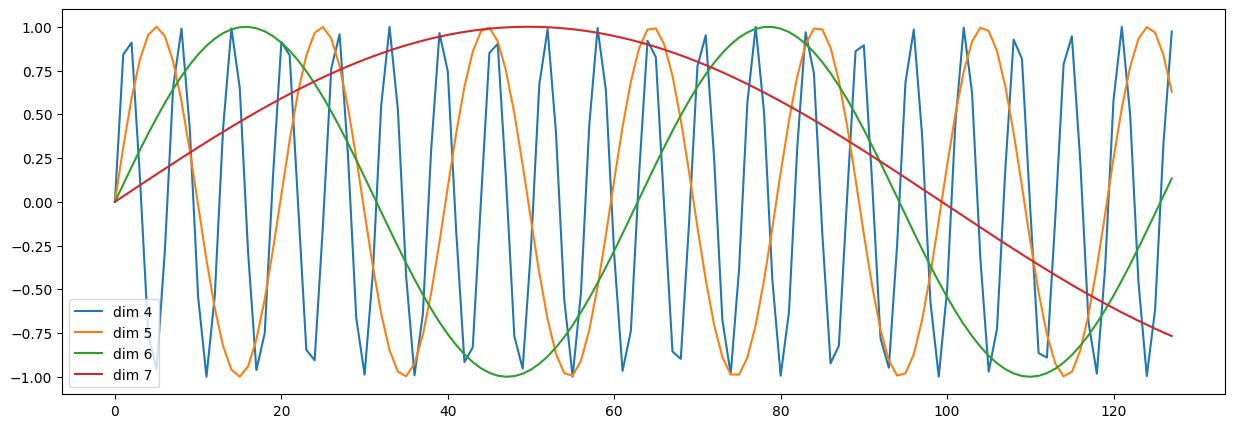

In [20]:
# 1D Visualization
# create a PE for 100 data points, with model dimension 256.
pe = positional_encoding_1d(128, 128)
plt.figure(figsize=(15, 5))
plt.plot(np.arange(128), pe[:,0:63:16].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])


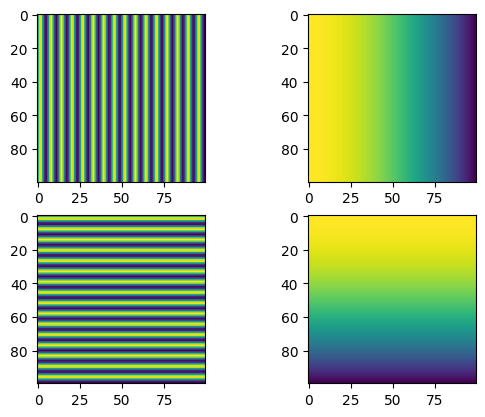

In [ ]:
# 2D Visualization
# create a PE for 100*100 image, with model dimension 128.
pe2 = positional_encoding_2d(128, 100, 100)
# show 4 different dimensions
plt.subplot(221)
plt.imshow(pe2[0,:,:])
plt.subplot(222)
plt.imshow(pe2[63,:,:])
plt.subplot(223)
plt.imshow(pe2[64,:,:])
plt.subplot(224)
plt.imshow(pe2[127,:,:])